In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns 
import warnings 
warnings.filterwarnings("ignore")

In [3]:
df=pd.read_csv("C:\\Users\\braab\\OneDrive\\Desktop\\House Price project\\housing.csv")

In [4]:
df.head(10)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
5,-122.25,37.85,52.0,919.0,213.0,413.0,193.0,4.0368,269700.0,NEAR BAY
6,-122.25,37.84,52.0,2535.0,489.0,1094.0,514.0,3.6591,299200.0,NEAR BAY
7,-122.25,37.84,52.0,3104.0,687.0,1157.0,647.0,3.1200,241400.0,NEAR BAY
8,-122.26,37.84,42.0,2555.0,665.0,1206.0,595.0,2.0804,226700.0,NEAR BAY
9,-122.25,37.84,52.0,3549.0,707.0,1551.0,714.0,3.6912,261100.0,NEAR BAY


In [ ]:
# some of Sanity checks and some info 
df["ocean_proximity"].value_counts()# making for the data type which is obj 

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [6]:
def check_data_types_shape(data):
    print("Data types of the columns are : \n",data.dtypes)
    print("\n")
    print("Shape of the data is : ",data.shape)
    print("\n")
    print("Info of the data is : \n",data.info())
    print("\n")
    print("Description of the data is : \n",data.describe())
check_data_types_shape(df)


Data types of the columns are : 
 longitude             float64
latitude              float64
housing_median_age    float64
total_rooms           float64
total_bedrooms        float64
population            float64
households            float64
median_income         float64
median_house_value    float64
ocean_proximity           str
dtype: object


Shape of the data is :  (20640, 10)


<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value 

In [12]:
def check_missing_value(data):
    print("Missing values in the data are : \n",data.isnull().sum())
    print("\n")
    print("pecentage of missning values :",(data.isnull().sum()/data.shape[0])*100)
    print("\n")
check_missing_value(df)



Missing values in the data are : 
 longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64


pecentage of missning values : longitude             0.000000
latitude              0.000000
housing_median_age    0.000000
total_rooms           0.000000
total_bedrooms        1.002907
population            0.000000
households            0.000000
median_income         0.000000
median_house_value    0.000000
ocean_proximity       0.000000
dtype: float64




Feature name :  longitude
mean of the longitude : -119.57
median of the longitude : -118.49
mode of the longitude : -118.31


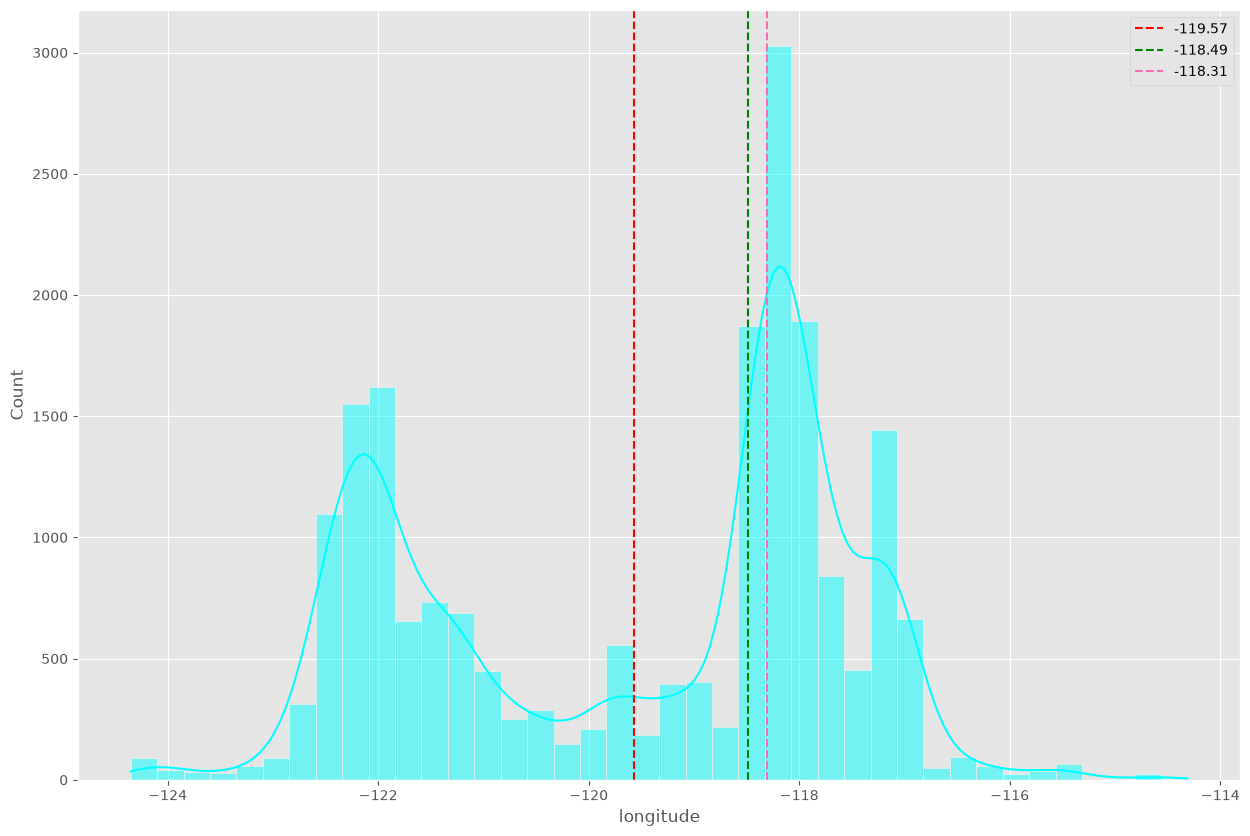



Difference between mean and median :1.08
Distribution is negatively skewed (-ve skewed)
Feature name :  latitude
mean of the latitude : 35.63
median of the latitude : 34.26
mode of the latitude : 34.06


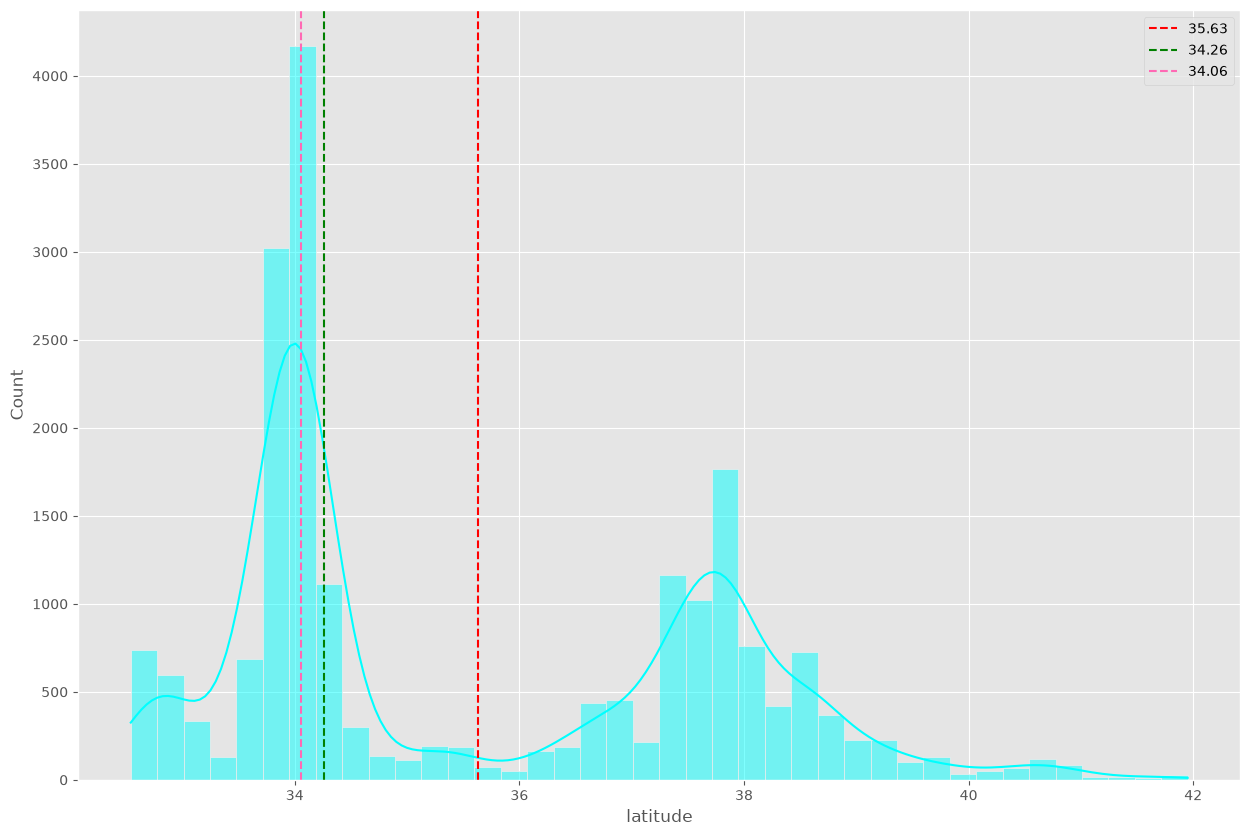



Difference between mean and median :1.37
Distribution is positively skewed (+ve skewed)
Feature name :  housing_median_age
mean of the housing_median_age : 28.64
median of the housing_median_age : 29.00
mode of the housing_median_age : 52.00


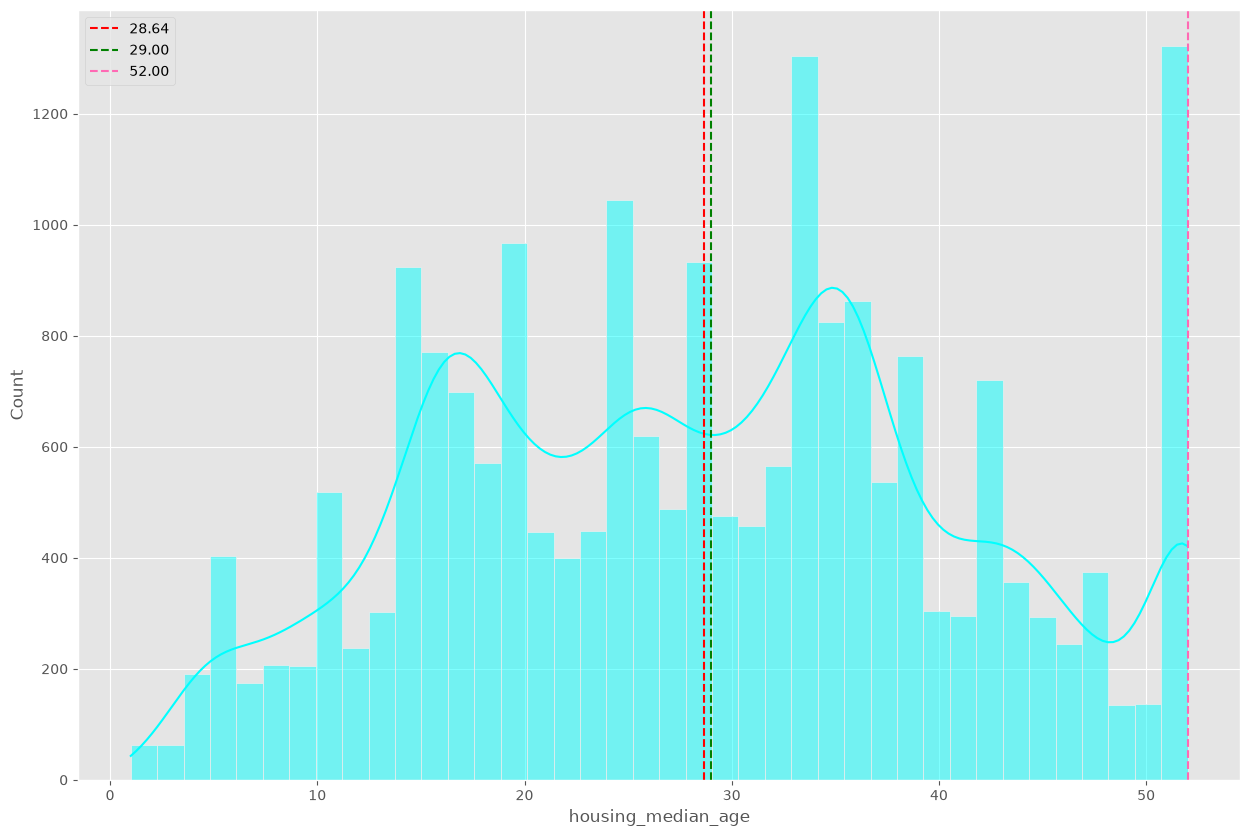



Difference between mean and median :0.36
Distribution is negatively skewed (-ve skewed)
Feature name :  total_rooms
mean of the total_rooms : 2635.76
median of the total_rooms : 2127.00
mode of the total_rooms : 1527.00


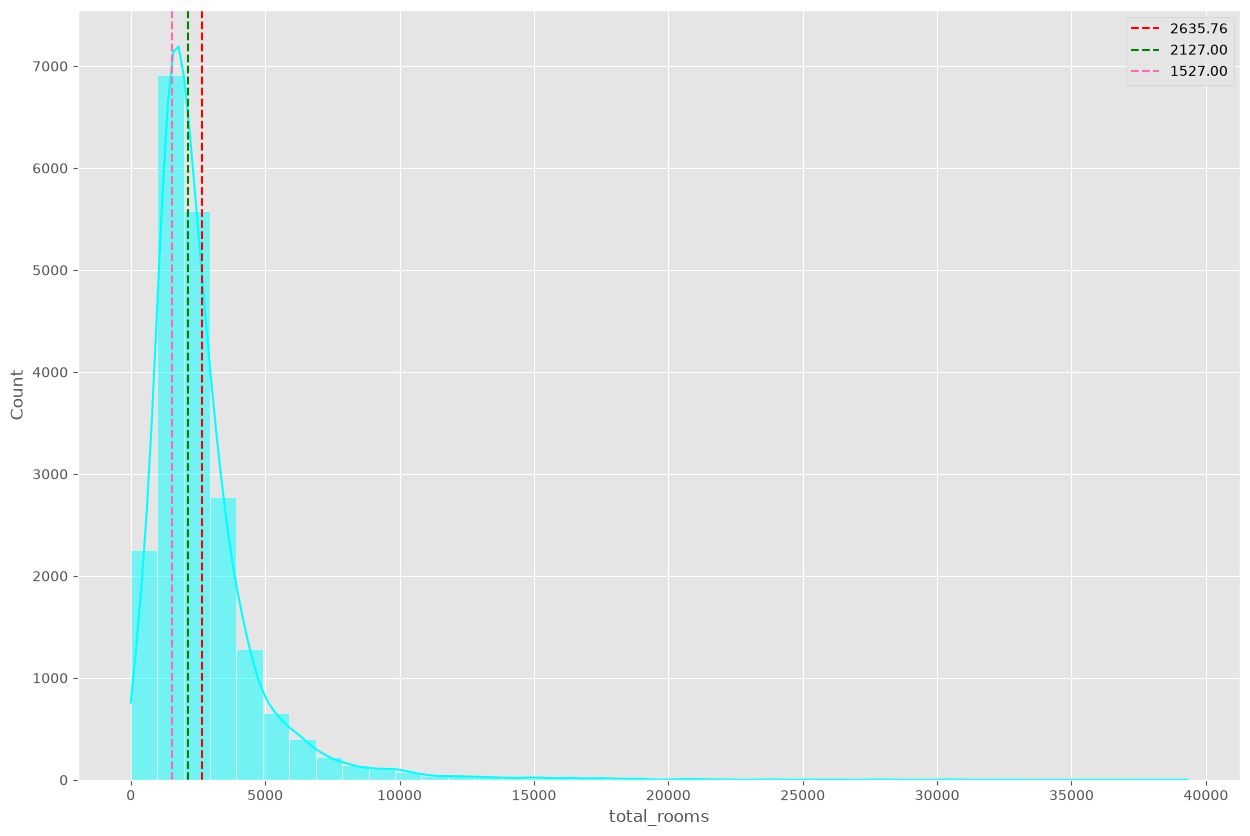



Difference between mean and median :508.76
Distribution is positively skewed (+ve skewed)
Feature name :  total_bedrooms
mean of the total_bedrooms : 537.87
median of the total_bedrooms : 435.00
mode of the total_bedrooms : 280.00


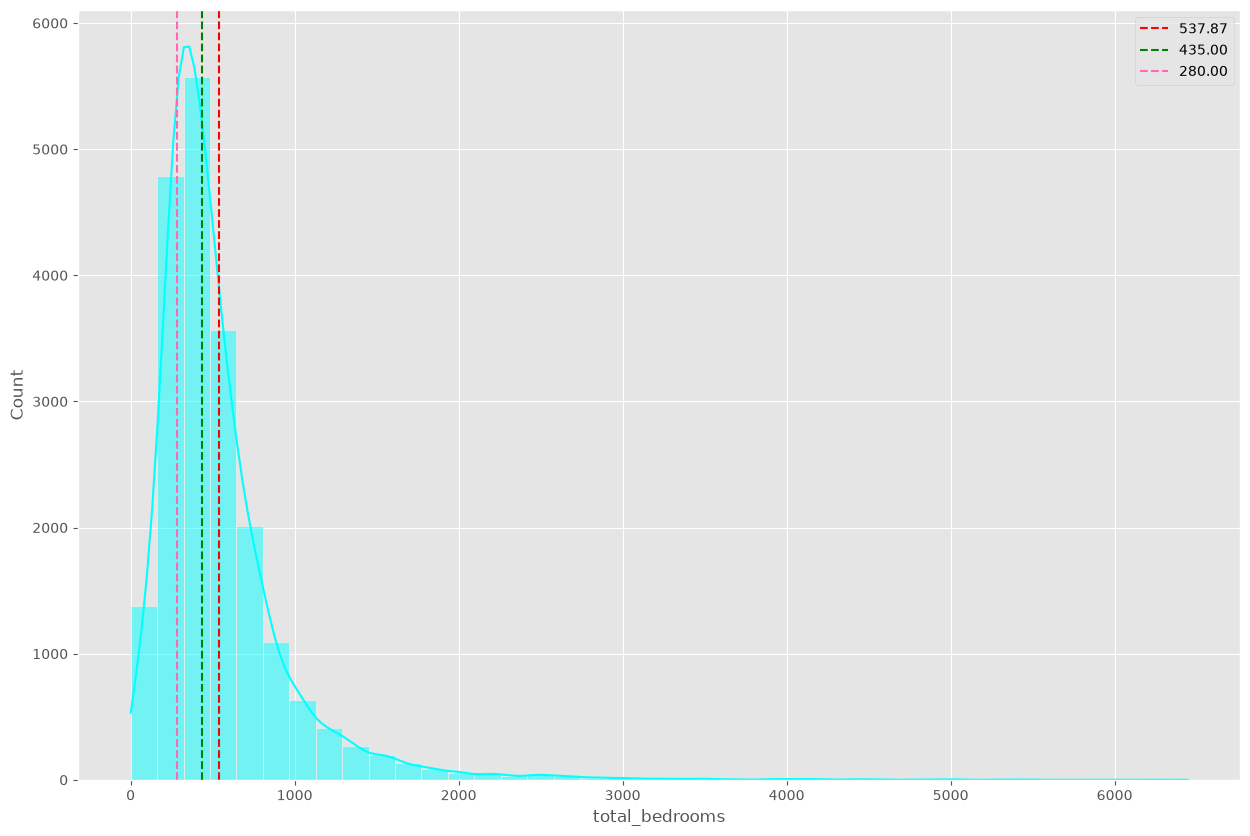



Difference between mean and median :102.87
Distribution is positively skewed (+ve skewed)
Feature name :  population
mean of the population : 1425.48
median of the population : 1166.00
mode of the population : 891.00


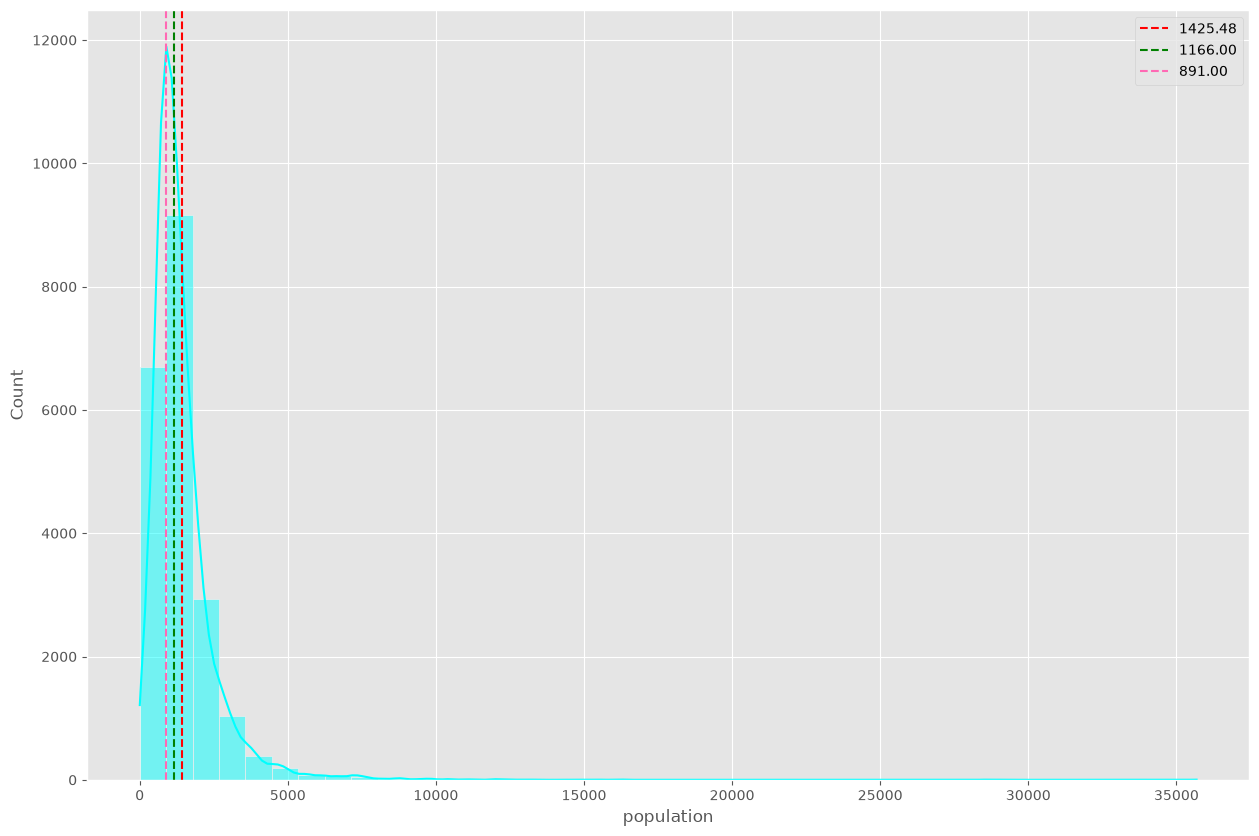



Difference between mean and median :259.48
Distribution is positively skewed (+ve skewed)
Feature name :  households
mean of the households : 499.54
median of the households : 409.00
mode of the households : 306.00


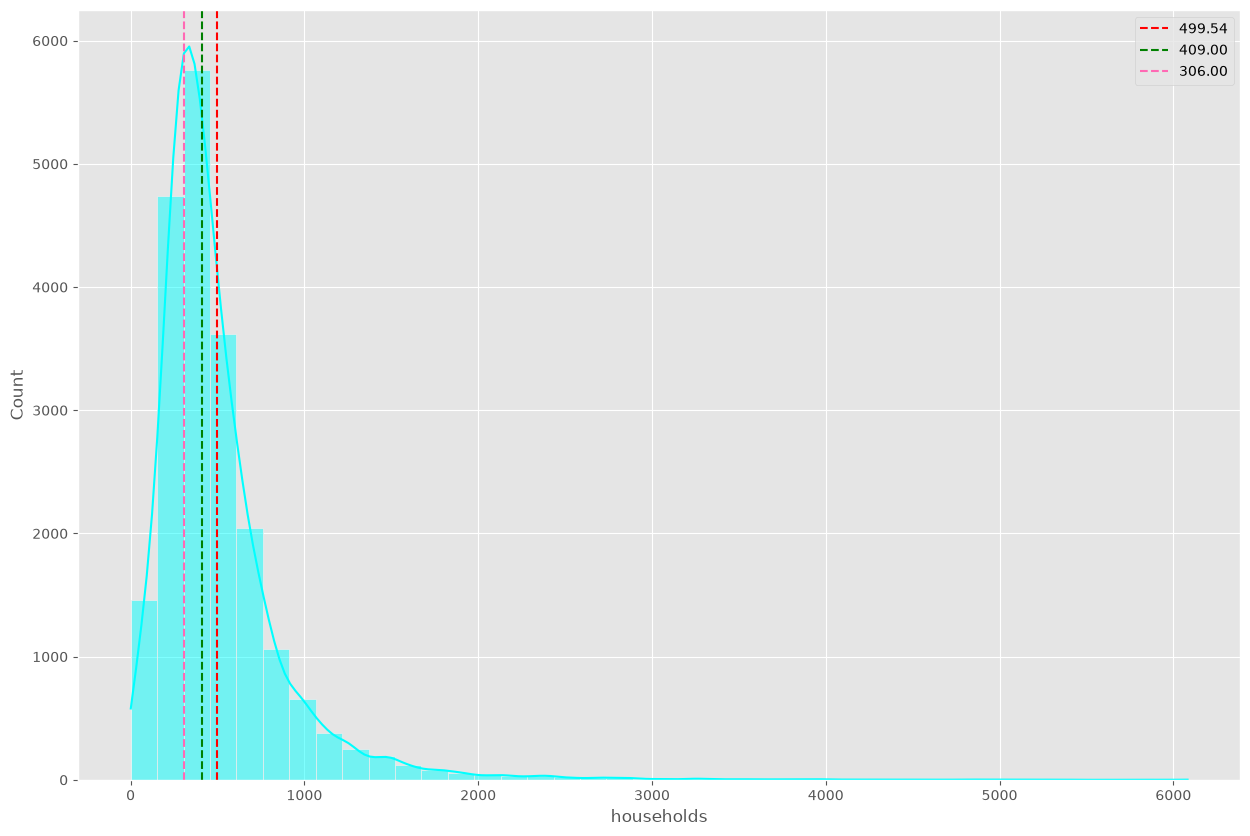



Difference between mean and median :90.54
Distribution is positively skewed (+ve skewed)
Feature name :  median_income
mean of the median_income : 3.87
median of the median_income : 3.53
mode of the median_income : 3.12


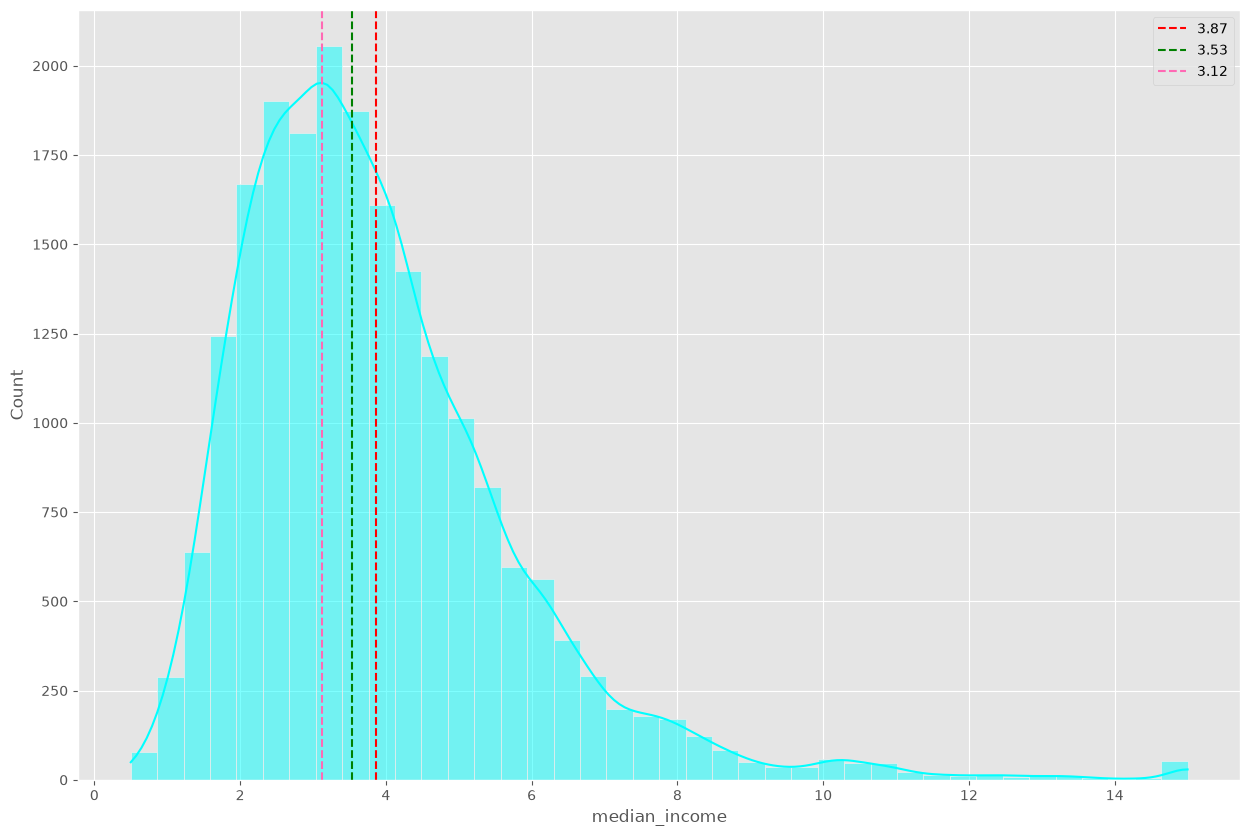



Difference between mean and median :0.34
Distribution is positively skewed (+ve skewed)
Feature name :  median_house_value
mean of the median_house_value : 206855.82
median of the median_house_value : 179700.00
mode of the median_house_value : 500001.00


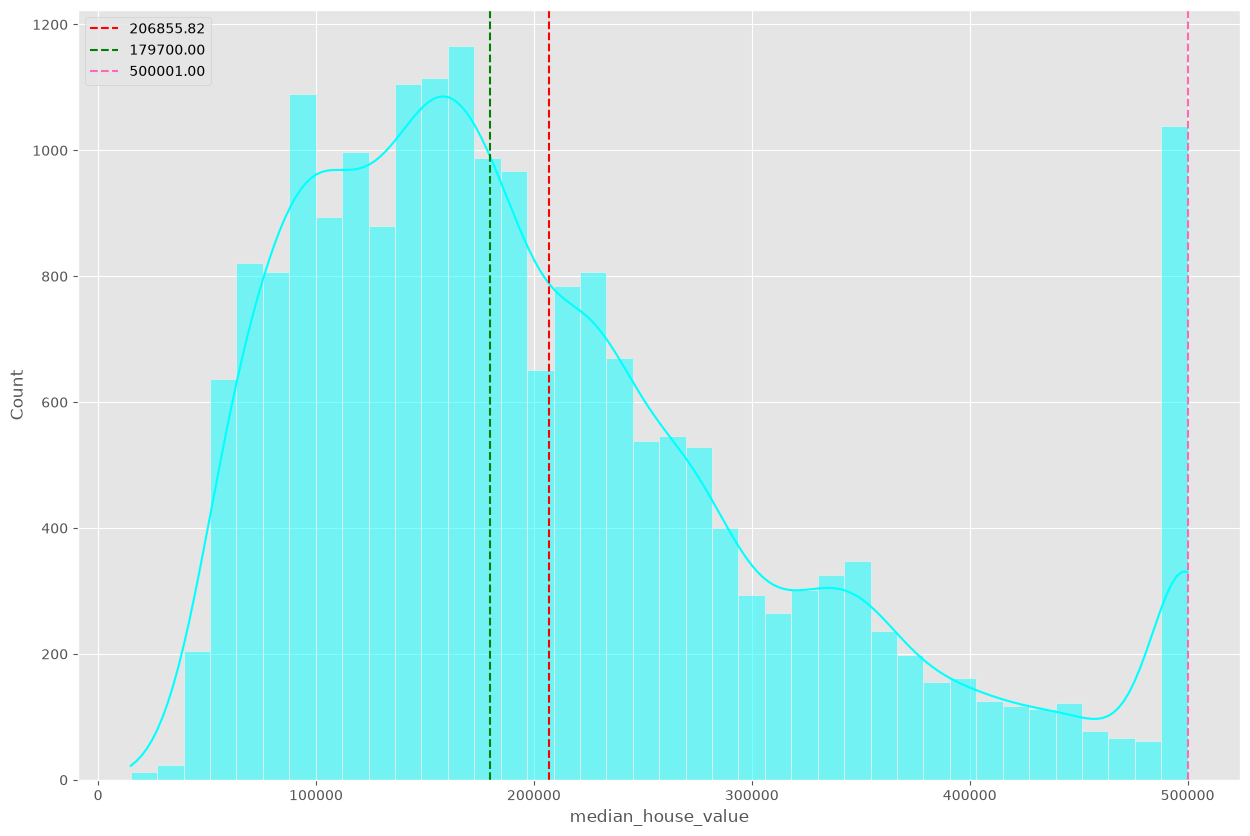



Difference between mean and median :27155.82
Distribution is positively skewed (+ve skewed)


In [15]:
plt.style.use("ggplot")
from scipy import stats
def distribution(data,feature):
    mean=data[feature].mean()
    median=data[feature].median()
    mode=data[feature].mode()[0]
    difference=abs(mean-median)
    print("Feature name : ",feature)
    print(f"mean of the {feature} : {mean:.2f}")
    print(f"median of the {feature} : {median:.2f}")
    print(f"mode of the {feature} : {mode:.2f}")
    plt.figure(figsize=(15,10))
    sns.histplot(data[feature],color="cyan",kde=True,bins=40)
    plt.axvline(mean,color="red",label=f"{mean:.2f}",linestyle="--")
    plt.axvline(median,color="green",label=f"{median:.2f}",linestyle="--")
    plt.axvline(mode,color="hotpink",label=f"{mode:.2f}",linestyle="--")
    plt.legend()

    plt.show()
    print("\n")
    print(f"Difference between mean and median :{difference:.2f}")
    
    if mean > median:
        print("Distribution is positively skewed (+ve skewed)")
    elif mean < median:
        print("Distribution is negatively skewed (-ve skewed)")
    else:
        print("Mean ≈ Median → distribution may be approximately symmetric")   
df_numeric_cols=df.select_dtypes(include=np.number).columns
for col in df_numeric_cols:
    distribution(df,col)